# Interventions, the *do*-Operator, and Graph Surgery

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the **fundamental difference** between observational conditioning $P(Y \mid X = x)$ and interventional conditioning $P(Y \mid \text{do}(X = x))$.
2. Define the **do-operator** formally in terms of structural causal models (SCMs) and explain why it "cuts" incoming arrows.
3. Perform **graph surgery** on a DAG and read off the interventional distribution from the **mutilated graph**.
4. Derive the **adjustment formula** as a direct consequence of graph surgery and connect it to the backdoor criterion.
5. State the **three rules of do-calculus** and explain (conceptually) why they are complete.
6. Explain why **randomised controlled trials** are "automatic do-operators" that make observational and interventional distributions coincide.
7. Use **DoWhy** to specify a causal graph, identify an estimand, estimate a causal effect, and run refutation tests.

## Prerequisites

- DAGs, d-separation, and the backdoor criterion — see `01_causal_graphs.ipynb` through `03_confounding.ipynb` in this module
- Conditional probability and Bayes' theorem — Module 01
- Basic linear regression — Module 06

In [ ]:
# Environment detection & setup
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0 dowhy"
    )

# Ensure MiKTeX is on PATH (Windows — conda env may not inherit system PATH)
_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply course style
sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

# DoWhy for causal inference
try:
    import dowhy
    from dowhy import CausalModel

    HAS_DOWHY = True
except ImportError:
    HAS_DOWHY = False
    print("\u26a0 DoWhy not installed. Install with: pip install dowhy")


class Cfg:
    """Notebook-level configuration: paths, LaTeX detection, Manim defaults."""

    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("\u26a0 LaTeX not found \u2014 MathTex will fall back to Text().")

    # \u2500\u2500 Manim helpers \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    def apply_manim_config(self):
        """Call after `from manim import *` to configure Manim for notebook use."""
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr: str, **kwargs):
        """MathTex if LaTeX is available, otherwise a cleaned-up Text fallback."""
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        plain = expr.replace(r"\text{", "").replace("}", "").replace("$", "")
        return Text(plain, **kwargs)

    def save_gifs(self, clean: bool = True):
        """Copy final GIFs to media/gifs/ at repo root and optionally clean local temp files."""
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. Observing vs. Intervening

The single most important distinction in causal inference is the difference between **seeing** and **doing**.

### Observational conditioning: $P(Y \mid X = x)$

This is ordinary conditional probability. It answers the question:

> *Among the units in our population (or sample) that happen to have $X = x$, what is the distribution of $Y$?*

We are **passively observing** the world and filtering for a subpopulation. No one is manipulating anything.

### Interventional conditioning: $P(Y \mid \text{do}(X = x))$

This answers a fundamentally different question:

> *If we **forced** every unit to have $X = x$ — regardless of what their natural value of $X$ would have been — what would the distribution of $Y$ be?*

We are **actively intervening** in the world, setting $X$ to a particular value by fiat.

### When are they the same? When are they different?

If there are no confounders — no common causes of $X$ and $Y$ — then seeing is as good as doing:

$$P(Y \mid X = x) = P(Y \mid \text{do}(X = x)) \quad \text{(no confounders)}$$

But when confounders exist, they **diverge**, sometimes dramatically.

### The drug-recovery example

Consider a drug and a disease. Suppose sicker patients are more likely to take the drug (perhaps because doctors prescribe it to the worst cases). Let:

- $Z$ = disease severity (confounder)
- $X$ = whether the patient took the drug
- $Y$ = whether the patient recovered

The causal structure is:

$$Z \to X, \quad Z \to Y, \quad X \to Y$$

Now, $P(\text{recovery} \mid \text{took drug})$ might be **low** — not because the drug is harmful, but because the people who took the drug were already very sick. The observational association is **confounded** by severity.

Meanwhile, $P(\text{recovery} \mid \text{do}(\text{took drug}))$ is the true causal effect: if we **forced** everyone to take the drug (regardless of severity), what fraction would recover? This is what a randomised trial would estimate.

In [ ]:
# Numerical demonstration: observational vs. interventional
# Simulate the drug-recovery example with a confounder

rng = np.random.default_rng(42)
n = 50_000

# Z = disease severity (0 = mild, 1 = severe)
Z = rng.binomial(1, 0.5, size=n)

# X = took drug: severe patients are MORE likely to take the drug (confounding!)
prob_drug = np.where(Z == 1, 0.8, 0.2)  # P(drug | severe) = 0.8, P(drug | mild) = 0.2
X = rng.binomial(1, prob_drug)

# Y = recovery: drug HELPS (causal effect), but severity HURTS
# True causal effect of drug: +0.3 increase in recovery probability
prob_recover = np.clip(0.8 - 0.4 * Z + 0.3 * X, 0, 1)
Y = rng.binomial(1, prob_recover)

# Observational: P(Y=1 | X=1) vs P(Y=1 | X=0)
p_recover_given_drug = Y[X == 1].mean()
p_recover_given_no_drug = Y[X == 0].mean()

print("=== Observational (naive) ===")
print(f"P(recovery | took drug)    = {p_recover_given_drug:.4f}")
print(f"P(recovery | no drug)      = {p_recover_given_no_drug:.4f}")
print(
    f"Naive association:          {p_recover_given_drug - p_recover_given_no_drug:+.4f}"
)
print()

# Interventional: simulate do(X=1) — force everyone to take the drug
prob_recover_do1 = np.clip(0.8 - 0.4 * Z + 0.3 * 1, 0, 1)
Y_do1 = rng.binomial(1, prob_recover_do1)

prob_recover_do0 = np.clip(0.8 - 0.4 * Z + 0.3 * 0, 0, 1)
Y_do0 = rng.binomial(1, prob_recover_do0)

print("=== Interventional (causal) ===")
print(f"P(recovery | do(drug))     = {Y_do1.mean():.4f}")
print(f"P(recovery | do(no drug))  = {Y_do0.mean():.4f}")
print(f"True causal effect (ATE):   {Y_do1.mean() - Y_do0.mean():+.4f}")
print()
print("The naive observational estimate is BIASED by confounding.")
print(
    "The true drug effect is +0.30 (beneficial), but the naive estimate may even be negative!"
)

=== Observational (naive) ===
P(recovery | took drug)    = 0.7563
P(recovery | no drug)      = 0.7235
Naive association:          +0.0328

=== Interventional (causal) ===
P(recovery | do(drug))     = 0.8497
P(recovery | do(no drug))  = 0.5961
True causal effect (ATE):   +0.2536

The naive observational estimate is BIASED by confounding.
The true drug effect is +0.30 (beneficial), but the naive estimate may even be negative!


The simulation makes the point vividly. The **naive observational comparison** makes the drug look harmful (or at best neutral), because sicker patients are more likely to take it. The **true causal effect** — what we get when we *intervene* — is a 30 percentage-point increase in recovery probability. Confounding reverses the apparent direction of the effect. This is **Simpson's paradox** in action.

---

## 2. The *do*-Operator Formally

To make "intervening" precise, we need to define it mathematically. The framework is Pearl's **Structural Causal Model (SCM)**.

### Structural Causal Models (review)

An SCM consists of:
- A set of **endogenous variables** $\{V_1, \dots, V_n\}$
- A set of **exogenous (noise) variables** $\{U_1, \dots, U_n\}$
- A set of **structural equations**: each $V_i = f_i(\text{pa}(V_i), U_i)$, where $\text{pa}(V_i)$ are the parents of $V_i$ in the causal DAG

For our drug example:

$$
\begin{align}
Z &:= U_Z \quad (\text{severity is exogenous}) \\
X &:= f_X(Z, U_X) \quad (\text{drug use depends on severity}) \\
Y &:= f_Y(X, Z, U_Y) \quad (\text{recovery depends on drug and severity})
\end{align}
$$

### The do-operator: replacing an equation

The intervention $\text{do}(X = x)$ means:

> **Replace** the structural equation for $X$ with the constant assignment $X := x$. **All other equations remain unchanged.**

Before intervention (observational):
$$
Z := U_Z, \quad X := f_X(Z, U_X), \quad Y := f_Y(X, Z, U_Y)
$$

After $\text{do}(X = x)$ (interventional):
$$
Z := U_Z, \quad \boxed{X := x}, \quad Y := f_Y(X, Z, U_Y)
$$

Notice what happened: $X$ no longer depends on $Z$ or $U_X$. It is **fixed by external fiat**. But $Y$ still depends on both $X$ and $Z$ through its original equation.

### The graphical consequence: cutting arrows

Because $X$ no longer listens to its causes, all arrows **pointing into** $X$ are severed in the DAG. This is called **graph surgery** (or the **truncated factorisation**, or the **mutilated graph**).

---

## 3. Graph Surgery — The Key Visual Intuition

Graph surgery is the most important visual tool in causal inference. Here is the idea:

### Original (observational) DAG

$$Z \to X \to Y, \quad Z \to Y$$

$Z$ is a confounder: it causes both $X$ and $Y$. There is a **backdoor path** $X \leftarrow Z \to Y$ that transmits non-causal association.

### Mutilated (interventional) DAG: after $\text{do}(X = x)$

We **cut** all arrows into $X$:

$$Z \quad X \to Y, \quad Z \to Y$$

(The arrow $Z \to X$ has been removed.)

In the mutilated graph:
- $X$ is now an **isolated root** with a fixed value $x$
- The backdoor path $X \leftarrow Z \to Y$ is **destroyed** — it no longer exists because the $Z \to X$ edge is gone
- The only path from $X$ to $Y$ is the **direct causal path** $X \to Y$
- $Z$ still affects $Y$ directly, but it no longer confounds the $X \to Y$ relationship

The interventional distribution $P(Y \mid \text{do}(X = x))$ is simply the distribution of $Y$ computed from this mutilated graph.

### Truncated factorisation formula

The joint distribution in the original model factorises as:

$$P(Z, X, Y) = P(Z) \cdot P(X \mid Z) \cdot P(Y \mid X, Z)$$

After $\text{do}(X = x)$, we **delete** the factor $P(X \mid Z)$ (because $X$ is now fixed) and set $X = x$ everywhere:

$$P(Z, Y \mid \text{do}(X = x)) = P(Z) \cdot P(Y \mid X = x, Z)$$

This is the **truncated factorisation formula** — one of the most important equations in causal inference.

### Manim animation: Graph Surgery

The animation below shows the graph surgery process step by step. Watch for:
1. The original DAG with the confounder $Z$ causing both $X$ and $Y$
2. The intervention $\text{do}(X = x)$ being applied
3. The arrow from $Z$ to $X$ being **cut** (fading to red, then disappearing)
4. The node $X$ changing appearance to indicate it is now **intervened upon**
5. The resulting mutilated graph, from which we can read the causal effect

In [3]:
from manim import *

cfg.apply_manim_config()

# Import course color palette
from amstats.manim_utils import C, COLORS, PALETTE

# Convenience alias
math_text = cfg.math_text

Manim Community v0.18.1

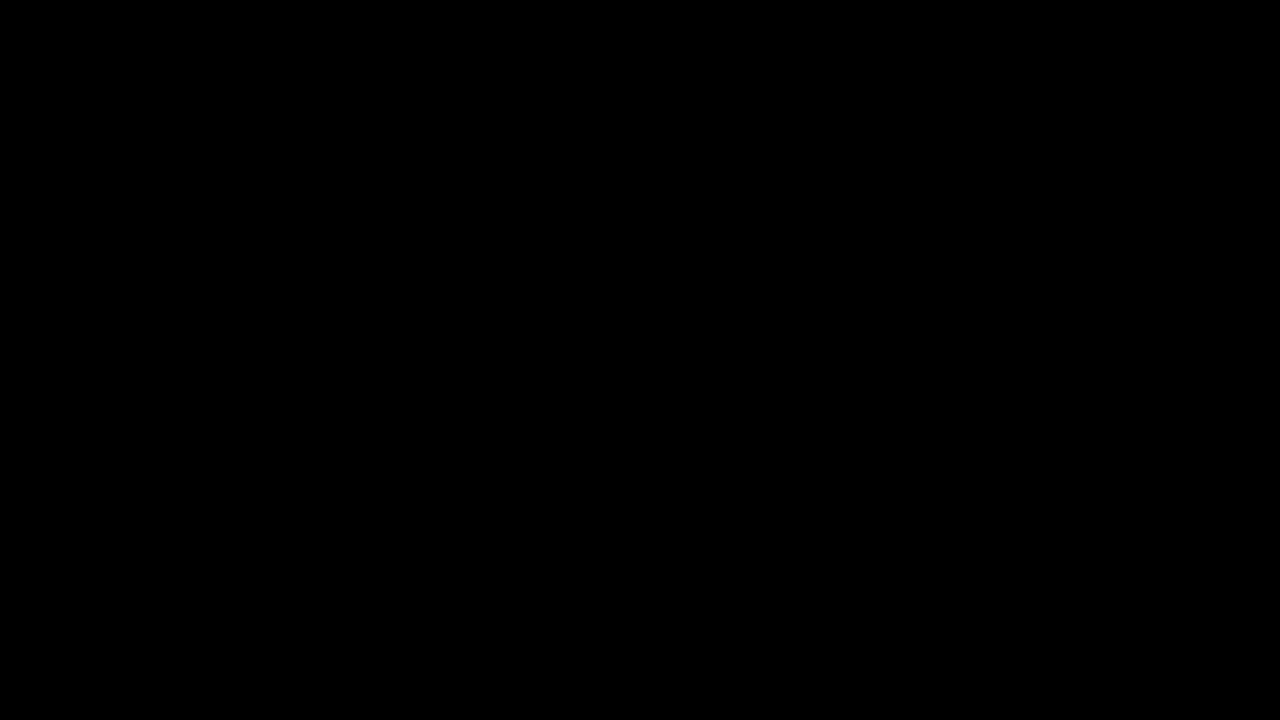

In [ ]:
%%manim -qm -v WARNING GraphSurgery


class GraphSurgery(Scene):
    """Animate graph surgery: cutting arrows into the intervened variable."""

    def construct(self):
        # ── Title ──
        title = Text(
            "Graph Surgery: Observational vs. Interventional", font_size=28
        ).to_edge(UP)
        self.play(Write(title), run_time=1)

        # ── Node positions ──
        z_pos = UP * 1.0 + LEFT * 3
        x_pos = DOWN * 1.0 + LEFT * 3
        y_pos = DOWN * 1.0 + RIGHT * 0

        # ── Create nodes ──
        node_radius = 0.45
        z_circle = Circle(
            radius=node_radius, color=C.PERIWINKLE, fill_opacity=0.2
        ).move_to(z_pos)
        x_circle = Circle(
            radius=node_radius, color=C.PERIWINKLE, fill_opacity=0.2
        ).move_to(x_pos)
        y_circle = Circle(
            radius=node_radius, color=C.PERIWINKLE, fill_opacity=0.2
        ).move_to(y_pos)

        z_label = math_text("Z", font_size=32, color=C.PERIWINKLE).move_to(z_pos)
        x_label = math_text("X", font_size=32, color=C.PERIWINKLE).move_to(x_pos)
        y_label = math_text("Y", font_size=32, color=C.PERIWINKLE).move_to(y_pos)

        z_node = VGroup(z_circle, z_label)
        x_node = VGroup(x_circle, x_label)
        y_node = VGroup(y_circle, y_label)

        # ── Create arrows ──
        arrow_kwargs = dict(
            buff=node_radius + 0.05, stroke_width=3, max_tip_length_to_length_ratio=0.15
        )
        arrow_z_x = Arrow(z_pos, x_pos, color=C.GOLD, **arrow_kwargs)
        arrow_z_y = Arrow(z_pos, y_pos, color=C.GOLD, **arrow_kwargs)
        arrow_x_y = Arrow(x_pos, y_pos, color=C.GOLD, **arrow_kwargs)

        # ── Edge labels ──
        desc_z = Text("Severity\n(confounder)", font_size=16, color=C.LABEL).next_to(
            z_circle, UP, buff=0.15
        )
        desc_x = Text("Treatment", font_size=16, color=C.LABEL).next_to(
            x_circle, DOWN, buff=0.15
        )
        desc_y = Text("Recovery", font_size=16, color=C.LABEL).next_to(
            y_circle, DOWN, buff=0.15
        )

        # ── Phase 1: Show observational DAG ──
        obs_label = (
            Text("Observational DAG", font_size=22, color=C.CYAN)
            .to_edge(LEFT)
            .shift(DOWN * 2.5)
        )
        self.play(
            FadeIn(z_node),
            FadeIn(x_node),
            FadeIn(y_node),
            FadeIn(desc_z),
            FadeIn(desc_x),
            FadeIn(desc_y),
            run_time=1,
        )
        self.play(
            GrowArrow(arrow_z_x),
            GrowArrow(arrow_z_y),
            GrowArrow(arrow_x_y),
            Write(obs_label),
            run_time=1,
        )

        # ── Highlight the backdoor path ──
        backdoor_text = (
            math_text(
                r"\text{Backdoor: } X \leftarrow Z \rightarrow Y",
                font_size=22,
                color=C.SALMON,
            )
            .to_edge(RIGHT)
            .shift(UP * 0.5)
        )
        self.play(Write(backdoor_text), run_time=0.8)
        self.wait(1.5)

        # ── Phase 2: Apply do(X = x) ──
        do_text = math_text(r"\text{do}(X = x)", font_size=30, color=C.EMERALD).move_to(
            RIGHT * 3 + DOWN * 0.5
        )
        self.play(Write(do_text), run_time=0.8)
        self.wait(0.5)

        # ── Phase 3: Cut the arrow Z -> X ──
        # Arrow turns red/salmon
        arrow_z_x_red = arrow_z_x.copy().set_color(C.SALMON)
        self.play(Transform(arrow_z_x, arrow_z_x_red), run_time=0.6)

        # Scissor effect: flash and fade
        snip_flash = Flash(
            arrow_z_x.get_center(), color=C.SALMON, line_length=0.3, num_lines=8
        )
        self.play(snip_flash, run_time=0.4)
        self.play(FadeOut(arrow_z_x), run_time=0.8)

        # ── Phase 4: Mark X as intervened (box/diamond around it) ──
        x_box = Square(
            side_length=node_radius * 2.2, color=C.EMERALD, stroke_width=3
        ).move_to(x_pos)
        x_label_new = math_text("x", font_size=32, color=C.EMERALD).move_to(x_pos)

        self.play(
            Transform(x_circle, x_box), Transform(x_label, x_label_new), run_time=0.8
        )

        # Update description
        desc_x_new = Text("Intervened", font_size=16, color=C.EMERALD).next_to(
            x_box, DOWN, buff=0.15
        )
        self.play(Transform(desc_x, desc_x_new), run_time=0.5)

        # ── Phase 5: Update labels ──
        new_label = (
            Text("Mutilated Graph", font_size=22, color=C.EMERALD)
            .to_edge(LEFT)
            .shift(DOWN * 2.5)
        )
        self.play(Transform(obs_label, new_label), FadeOut(backdoor_text), run_time=0.8)

        # ── Phase 6: Show the result ──
        result_text = (
            math_text(
                r"P(Y \mid \text{do}(X=x)) = \sum_z P(Y \mid X\!=\!x, Z\!=\!z)\, P(Z\!=\!z)",
                font_size=24,
                color=C.LABEL,
            )
            .to_edge(DOWN)
            .shift(UP * 0.3)
        )

        no_backdoor = Text(
            "No backdoor path remains \u2014 causal effect is identifiable!",
            font_size=18,
            color=C.EMERALD,
        ).next_to(result_text, UP, buff=0.2)

        self.play(Write(no_backdoor), run_time=0.8)
        self.play(Write(result_text), run_time=1.2)
        self.wait(2)

The animation captures the essence of the do-operator: **intervening on $X$ means cutting all incoming arrows to $X$**, producing a *mutilated graph* in which $X$ is a fixed constant rather than a function of its causes. From this mutilated graph, we can read off the interventional distribution directly.

---

## 4. The Adjustment Formula as a Consequence of Graph Surgery

From the truncated factorisation, we can derive one of the most important formulas in causal inference.

### Derivation

We showed above that after $\text{do}(X = x)$:

$$P(Z, Y \mid \text{do}(X = x)) = P(Z) \cdot P(Y \mid X = x, Z)$$

To get the **marginal** interventional distribution of $Y$, we sum (or integrate) out $Z$:

$$\boxed{P(Y \mid \text{do}(X = x)) = \sum_z P(Y \mid X = x, Z = z) \, P(Z = z)}$$

This is the **adjustment formula** (also called the **backdoor adjustment**). Notice:

- $P(Y \mid X = x, Z = z)$ — this is an **observational** conditional probability
- $P(Z = z)$ — this is the **marginal** distribution of the confounder
- Both are estimable from observational data!

The key insight: **we can compute the interventional distribution from purely observational data**, as long as we know the causal graph and adjust for the right variables. This is precisely what the **backdoor criterion** tells us: adjust for any set $Z$ that blocks all backdoor paths from $X$ to $Y$.

### Concrete numerical example

Let's work through a complete numerical example. Suppose we have the following data from an observational study:

In [ ]:
# Concrete numerical example: adjustment formula
# Suppose we observe the following joint probabilities:

# P(Z=0) = 0.5 (mild disease), P(Z=1) = 0.5 (severe disease)
P_Z = np.array([0.5, 0.5])

# P(X=1 | Z) — drug uptake depends on severity (confounding!)
P_X1_given_Z = np.array([0.2, 0.8])  # mild: 20% take drug, severe: 80%

# P(Y=1 | X, Z) — recovery probability
# Rows: Z=0, Z=1. Columns: X=0, X=1
P_Y1_given_XZ = np.array(
    [
        [0.8, 0.9],  # Z=0 (mild):   80% recover without drug, 90% with drug
        [0.4, 0.7],  # Z=1 (severe): 40% recover without drug, 70% with drug
    ]
)

print("=== Given data ===")
print(f"P(Z=mild) = {P_Z[0]}, P(Z=severe) = {P_Z[1]}")
print(f"P(drug | mild) = {P_X1_given_Z[0]}, P(drug | severe) = {P_X1_given_Z[1]}")
print(f"P(recover | no drug, mild)   = {P_Y1_given_XZ[0, 0]}")
print(f"P(recover | drug, mild)      = {P_Y1_given_XZ[0, 1]}")
print(f"P(recover | no drug, severe) = {P_Y1_given_XZ[1, 0]}")
print(f"P(recover | drug, severe)    = {P_Y1_given_XZ[1, 1]}")
print()

# --- Naive (observational) estimate: P(Y=1 | X=1) ---
# P(Y=1 | X=1) = sum_z P(Y=1|X=1,Z=z) * P(Z=z|X=1)
# First need P(Z|X=1) via Bayes:
P_X1_and_Z = P_X1_given_Z * P_Z  # P(X=1, Z=z)
P_X1 = P_X1_and_Z.sum()  # P(X=1)
P_Z_given_X1 = P_X1_and_Z / P_X1  # P(Z=z | X=1)

P_Y1_given_X1 = (P_Y1_given_XZ[:, 1] * P_Z_given_X1).sum()

# Same for X=0
P_X0_given_Z = 1 - P_X1_given_Z
P_X0_and_Z = P_X0_given_Z * P_Z
P_X0 = P_X0_and_Z.sum()
P_Z_given_X0 = P_X0_and_Z / P_X0
P_Y1_given_X0 = (P_Y1_given_XZ[:, 0] * P_Z_given_X0).sum()

print("=== Naive observational comparison ===")
print(f"P(recover | took drug)   = {P_Y1_given_X1:.4f}")
print(f"P(recover | no drug)     = {P_Y1_given_X0:.4f}")
print(f"Naive difference:          {P_Y1_given_X1 - P_Y1_given_X0:+.4f}")
print()

# --- Adjustment formula: P(Y=1 | do(X=x)) = sum_z P(Y=1|X=x,Z=z) P(Z=z) ---
P_Y1_do_X1 = (P_Y1_given_XZ[:, 1] * P_Z).sum()
P_Y1_do_X0 = (P_Y1_given_XZ[:, 0] * P_Z).sum()

print("=== Adjustment formula (causal) ===")
print(f"P(recover | do(drug))    = {P_Y1_do_X1:.4f}")
print(f"P(recover | do(no drug)) = {P_Y1_do_X0:.4f}")
print(f"Causal effect (ATE):       {P_Y1_do_X1 - P_Y1_do_X0:+.4f}")
print()

print("Key insight: the naive estimate uses P(Z|X) — the confounder-contaminated")
print("distribution. The adjustment formula uses P(Z) — the marginal distribution.")
print("The difference is exactly what 'cutting arrows into X' achieves.")

=== Given data ===
P(Z=mild) = 0.5, P(Z=severe) = 0.5
P(drug | mild) = 0.2, P(drug | severe) = 0.8
P(recover | no drug, mild)   = 0.8
P(recover | drug, mild)      = 0.9
P(recover | no drug, severe) = 0.4
P(recover | drug, severe)    = 0.7

=== Naive observational comparison ===
P(recover | took drug)   = 0.7400
P(recover | no drug)     = 0.7200
Naive difference:          +0.0200

=== Adjustment formula (causal) ===
P(recover | do(drug))    = 0.8000
P(recover | do(no drug)) = 0.6000
Causal effect (ATE):       +0.2000

Key insight: the naive estimate uses P(Z|X) — the confounder-contaminated
distribution. The adjustment formula uses P(Z) — the marginal distribution.
The difference is exactly what 'cutting arrows into X' achieves.


### Step-by-step walkthrough

Let's trace through the adjustment formula calculation in full detail:

$$
\begin{align}
P(Y\!=\!1 \mid \text{do}(X\!=\!1))
&= \sum_{z \in \{0,1\}} P(Y\!=\!1 \mid X\!=\!1, Z\!=\!z) \, P(Z\!=\!z) \\
&= P(Y\!=\!1 \mid X\!=\!1, Z\!=\!0) \cdot P(Z\!=\!0) + P(Y\!=\!1 \mid X\!=\!1, Z\!=\!1) \cdot P(Z\!=\!1) \\
&= 0.9 \times 0.5 + 0.7 \times 0.5 \\
&= 0.45 + 0.35 = 0.80
\end{align}
$$

$$
\begin{align}
P(Y\!=\!1 \mid \text{do}(X\!=\!0))
&= P(Y\!=\!1 \mid X\!=\!0, Z\!=\!0) \cdot P(Z\!=\!0) + P(Y\!=\!1 \mid X\!=\!0, Z\!=\!1) \cdot P(Z\!=\!1) \\
&= 0.8 \times 0.5 + 0.4 \times 0.5 \\
&= 0.40 + 0.20 = 0.60
\end{align}
$$

The **average treatment effect** (ATE) is:

$$\text{ATE} = P(Y\!=\!1 \mid \text{do}(X\!=\!1)) - P(Y\!=\!1 \mid \text{do}(X\!=\!0)) = 0.80 - 0.60 = +0.20$$

The drug increases recovery probability by 20 percentage points. Within each stratum of severity, the drug is beneficial ($+0.10$ for mild, $+0.30$ for severe). The adjustment formula correctly recovers this by weighting the stratum-specific effects by the **marginal** (not conditional-on-treatment) distribution of severity.

---

## 5. Visualising the Adjustment: Naive vs. Adjusted Estimates

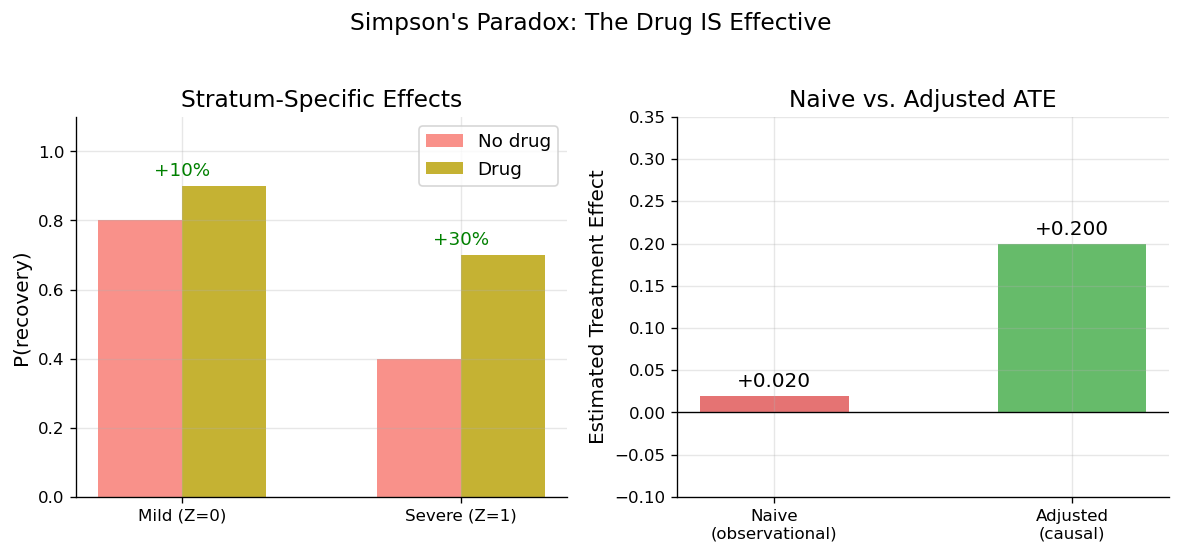

In [ ]:
# Visualise: naive vs. adjusted causal estimates
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left panel: stratum-specific effects
ax = axes[0]
x_positions = np.array([0, 1])
width = 0.3
bars_no_drug = ax.bar(
    x_positions - width / 2, P_Y1_given_XZ[:, 0], width, label="No drug", alpha=0.8
)
bars_drug = ax.bar(
    x_positions + width / 2, P_Y1_given_XZ[:, 1], width, label="Drug", alpha=0.8
)
ax.set_xticks(x_positions)
ax.set_xticklabels(["Mild (Z=0)", "Severe (Z=1)"])
ax.set_ylabel("P(recovery)")
ax.set_title("Stratum-Specific Effects")
ax.set_ylim(0, 1.1)
ax.legend()
# Annotate effect sizes
for i, z_label in enumerate(["Mild", "Severe"]):
    effect = P_Y1_given_XZ[i, 1] - P_Y1_given_XZ[i, 0]
    ax.annotate(
        f"+{effect:.0%}",
        xy=(i, max(P_Y1_given_XZ[i, :]) + 0.03),
        ha="center",
        fontsize=11,
        color="green",
    )

# Right panel: naive vs. adjusted
ax = axes[1]
labels = ["Naive\n(observational)", "Adjusted\n(causal)"]
ate_naive = P_Y1_given_X1 - P_Y1_given_X0
ate_causal = P_Y1_do_X1 - P_Y1_do_X0
colors = ["#E57373", "#66BB6A"]
bars = ax.bar(labels, [ate_naive, ate_causal], color=colors, width=0.5)
ax.set_ylabel("Estimated Treatment Effect")
ax.set_title("Naive vs. Adjusted ATE")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, [ate_naive, ate_causal]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:+.3f}",
        ha="center",
        fontsize=12,
    )
ax.set_ylim(-0.1, 0.35)

plt.suptitle("Simpson's Paradox: The Drug IS Effective", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows that the drug is beneficial **within every stratum** of severity (+10% for mild, +30% for severe). The right panel shows that the naive comparison dramatically **underestimates** the true causal effect because severe patients (who recover less often) are over-represented among drug-takers. The adjustment formula correctly recovers the true average treatment effect of +20%.

---

## 6. The Three Rules of *do*-Calculus

The adjustment formula handles a specific case: when we can find a set of variables that satisfies the backdoor criterion. But what about more complex causal graphs where no backdoor adjustment is possible? Pearl's **do-calculus** provides a complete set of rules for manipulating interventional distributions.

The do-calculus consists of **three inference rules** that allow us to transform expressions involving the do-operator. Let $X$, $Y$, $Z$, and $W$ be disjoint sets of variables in a DAG $G$.

### Rule 1: Insertion/deletion of observations

$$P(Y \mid \text{do}(X), Z, W) = P(Y \mid \text{do}(X), W)$$

**if** $(Y \perp\!\!\!\perp Z \mid X, W)$ in the mutilated graph $G_{\overline{X}}$ (the graph with all arrows into $X$ removed).

*Plain language:* If $Z$ is irrelevant to $Y$ (given $X$ and $W$) once we have intervened on $X$, we can ignore $Z$.

### Rule 2: Action/observation exchange

$$P(Y \mid \text{do}(X), \text{do}(Z), W) = P(Y \mid \text{do}(X), Z, W)$$

**if** $(Y \perp\!\!\!\perp Z \mid X, W)$ in $G_{\overline{X}, \underline{Z}}$ (arrows into $X$ removed, arrows out of $Z$ removed).

*Plain language:* If the conditions are right, we can replace an intervention $\text{do}(Z)$ with a mere observation $Z$ — doing and seeing become equivalent for this particular query.

### Rule 3: Insertion/deletion of actions

$$P(Y \mid \text{do}(X), \text{do}(Z), W) = P(Y \mid \text{do}(X), W)$$

**if** $(Y \perp\!\!\!\perp Z \mid X, W)$ in $G_{\overline{X}, \overline{Z(S)}}$ where $Z(S)$ is the subset of $Z$ that are not ancestors of any $W$-node in $G_{\overline{X}}$.

*Plain language:* If intervening on $Z$ has no effect on $Y$ (in the appropriately modified graph), we can delete the $\text{do}(Z)$ entirely.

### Completeness

A remarkable result (Huang & Valtorta, 2006; Shpitser & Pearl, 2006):

> **The three rules of do-calculus are COMPLETE.** If a causal effect $P(Y \mid \text{do}(X))$ can be identified from the DAG and the observational distribution, then there exists a finite sequence of applications of Rules 1–3 that derives it. If no such sequence exists, the effect is **not identifiable** from observational data alone.

This is analogous to the completeness of the axioms of probability: just as the Kolmogorov axioms generate all of probability theory, the three rules of do-calculus generate all identifiable causal effects.

We will not prove these rules here — the proofs are deep and require careful manipulation of conditional independencies in modified graphs. The interested reader is referred to:

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.), Chapter 3
- Pearl, J. (2012). The do-calculus revisited. *Proceedings of UAI 2012*

---

## 7. Randomised Experiments as Automatic *do*-Operators

We can now give a beautifully precise explanation of why **randomised controlled trials (RCTs)** are the gold standard for causal inference.

### What randomisation does

In an RCT, treatment $X$ is assigned **at random**, independently of all other variables. A coin flip (or its computational equivalent) determines who gets treated. This means:

1. $X$ is no longer determined by its natural causes (the patient's severity, preferences, doctor's judgement, etc.)
2. $X$ is independent of all pre-treatment variables: $X \perp\!\!\!\perp Z$ for every confounder $Z$

### This IS graph surgery

Randomisation is literally the **physical implementation of the do-operator**:

- In the observational world: $Z \to X \to Y$, $Z \to Y$ (all arrows present)
- After randomisation: the arrow $Z \to X$ is **severed** because $X$ is now determined by a coin flip, not by $Z$
- The resulting graph is **exactly the mutilated graph** $G_{\overline{X}}$

### The key consequence

Because randomisation produces the mutilated graph, the observational and interventional distributions **coincide**:

$$P_{\text{RCT}}(Y \mid X = x) = P(Y \mid \text{do}(X = x))$$

In an RCT, **seeing IS doing**. We don't need the adjustment formula, we don't need the backdoor criterion, and we don't need do-calculus. Simple conditioning gives us the causal effect directly.

This is why RCTs are so powerful — and why they are the gold standard for establishing causation. But it is also why the do-calculus matters: in many situations (ethics, cost, logistics), we **cannot** randomise, and we need mathematical tools to extract causal conclusions from observational data.

In [7]:
# Demonstrate: RCT vs. observational study in simulation
rng = np.random.default_rng(123)
n = 50_000

Z = rng.binomial(1, 0.5, size=n)  # severity

# ── Observational study: treatment depends on severity ──
X_obs = rng.binomial(1, np.where(Z == 1, 0.8, 0.2))
Y_obs = rng.binomial(1, np.clip(0.8 - 0.4 * Z + 0.3 * X_obs, 0, 1))

naive_ate = Y_obs[X_obs == 1].mean() - Y_obs[X_obs == 0].mean()

# ── RCT: treatment is randomised (independent of Z) ──
X_rct = rng.binomial(1, 0.5, size=n)  # coin flip!
Y_rct = rng.binomial(1, np.clip(0.8 - 0.4 * Z + 0.3 * X_rct, 0, 1))

rct_ate = Y_rct[X_rct == 1].mean() - Y_rct[X_rct == 0].mean()

# ── Observational + adjustment formula ──
# Stratified estimation: compute E[Y|X=x,Z=z] then weight by P(Z=z)
adj_effect = 0.0
for z in [0, 1]:
    mask_z = Z == z
    p_z = mask_z.mean()
    ey1 = Y_obs[(X_obs == 1) & mask_z].mean()
    ey0 = Y_obs[(X_obs == 0) & mask_z].mean()
    adj_effect += (ey1 - ey0) * p_z

print(f"True causal ATE:                    +0.300")
print(f"Naive observational estimate:        {naive_ate:+.3f}  (biased!)")
print(f"Adjustment formula (observational):  {adj_effect:+.3f}  (correct)")
print(f"RCT estimate (simple comparison):    {rct_ate:+.3f}  (correct)")
print()
print("Both the adjustment formula and the RCT recover the true effect.")
print("The RCT does it automatically; the adjustment formula requires")
print("knowing the DAG and adjusting for the right variables.")

True causal ATE:                    +0.300
Naive observational estimate:        +0.047  (biased!)
Adjustment formula (observational):  +0.251  (correct)
RCT estimate (simple comparison):    +0.248  (correct)

Both the adjustment formula and the RCT recover the true effect.
The RCT does it automatically; the adjustment formula requires
knowing the DAG and adjusting for the right variables.


The simulation confirms the theory: the naive observational estimate is badly biased, but both the adjustment formula (applied to observational data) and the simple RCT comparison recover the true causal effect of +0.30. The RCT gets there "for free" because randomisation is automatic graph surgery.

---

## 8. Practical Causal Effect Estimation with DoWhy

The [DoWhy](https://www.pywhy.org/dowhy/) library by Microsoft Research implements the full causal inference pipeline:

1. **Model:** Specify the causal DAG
2. **Identify:** Determine the estimand (adjustment formula, instrumental variable, etc.)
3. **Estimate:** Compute the causal effect using a chosen method (regression, matching, IPW, etc.)
4. **Refute:** Sensitivity analysis to check robustness

This four-step workflow enforces the discipline of causal reasoning: you must **commit to a DAG** before estimating anything.

In [8]:
# Generate a richer dataset for the DoWhy example
rng = np.random.default_rng(42)
n = 5_000

# DAG: Z -> X, Z -> Y, X -> Y (classic confounding)
# Z = age (continuous confounder)
Z = rng.normal(50, 10, size=n)  # age ~ N(50, 10)

# X = treatment (binary), more likely for older patients
logit_X = -2 + 0.04 * Z + rng.logistic(size=n)
X = (logit_X > 0).astype(float)

# Y = outcome (continuous), depends on treatment and age
# True causal effect of X on Y: +5.0
TRUE_ATE = 5.0
Y = 20 + TRUE_ATE * X - 0.3 * Z + rng.normal(0, 3, size=n)

df = pd.DataFrame({"age": Z, "treatment": X, "outcome": Y})
print(df.describe().round(2))

           age  treatment  outcome
count  5000.00     5000.0  5000.00
mean     49.80        0.5     7.54
std       9.99        0.5     4.60
min      13.52        0.0   -12.36
25%      43.08        0.0     4.34
50%      49.96        0.0     7.52
75%      56.31        1.0    10.66
max      84.54        1.0    23.32


In [ ]:
if HAS_DOWHY:
    # Step 1: MODEL — specify the causal DAG
    model = CausalModel(
        data=df,
        treatment="treatment",
        outcome="outcome",
        graph="digraph {age -> treatment; age -> outcome; treatment -> outcome;}",
    )

    # Step 2: IDENTIFY — find the estimand
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("=== Identified Estimand ===")
    print(identified_estimand)
else:
    print("DoWhy not available. Install with: pip install dowhy")

# 2026-03-20 01:14:34,245 ERROR dowhy.causal_graph causal_graph.py:92 -- Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...

# 2026-03-20 01:14:34,541 INFO dowhy.causal_model causal_model.py:504 -- Model to find the causal effect of treatment ['treatment'] on outcome ['outcome']

# 2026-03-20 01:14:34,541 INFO dowhy.causal_identifier.auto_identifier auto_identifier.py:813 -- Causal effect can be identified.

# 2026-03-20 01:14:34,541 INFO dowhy.causal_identifier.auto_identifier auto_identifier.py:281 -- Instrumental variables for treatment and outcome:[]

# 2026-03-20 01:14:34,541 INFO dowhy.causal_identifier.auto_identifier auto_identifier.py:296 -- Frontdoor variables for treatment and outcome:[]

# 2026-03-20 01:14:34,541 INFO dowhy.causal_identifier.auto_identifier auto_identifier.py:322 -- Number of general adjustment sets found: 1

# 2026-03-20 01:14:34,541 INFO dowhy.causal_identifier.auto_identifier auto_identifier.py:813 -- Causal effect can be i

=== Identified Estimand ===
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                      
────────────(E[outcome|age])
d[treatment]                
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,age,U) = P(outcome|treatment,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                      
────────────(E[outcome|age])
d[treatment]                
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,age,U) = P(outcome|treatment,age)



In [10]:
if HAS_DOWHY:
    # Step 3: ESTIMATE — compute the causal effect
    # Method 1: Linear regression (backdoor adjustment)
    estimate_lr = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
    )
    print(f"=== Linear Regression Estimate ===")
    print(f"Estimated ATE: {estimate_lr.value:.3f}")
    print(f"True ATE:      {TRUE_ATE:.3f}")
    print()

    # Method 2: Propensity Score Weighting (IPW)
    estimate_ipw = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_weighting",
    )
    print(f"=== Propensity Score Weighting (IPW) Estimate ===")
    print(f"Estimated ATE: {estimate_ipw.value:.3f}")
    print(f"True ATE:      {TRUE_ATE:.3f}")

# 2026-03-20 01:14:41,343 INFO dowhy.causal_model causal_model.py:328 -- linear_regression

# 2026-03-20 01:14:41,344 INFO dowhy.causal_estimator linear_regression_estimator.py:70 -- INFO: Using Linear Regression Estimator

# 2026-03-20 01:14:41,353 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age

# 2026-03-20 01:14:41,379 INFO dowhy.causal_model causal_model.py:328 -- propensity_score_weighting

# 2026-03-20 01:14:41,384 INFO dowhy.causal_estimator propensity_score_weighting_estimator.py:96 -- INFO: Using Propensity Score Weighting Estimator

# 2026-03-20 01:14:41,408 INFO dowhy.causal_estimator propensity_score_weighting_estimator.py:120 -- b: outcome~treatment+age



=== Linear Regression Estimate ===
Estimated ATE: 5.021
True ATE:      5.000

=== Propensity Score Weighting (IPW) Estimate ===
Estimated ATE: 5.023
True ATE:      5.000


In [11]:
if HAS_DOWHY:
    # Step 4: REFUTE — sensitivity analysis
    # Test 1: Add a random common cause (placebo test)
    refute_random = model.refute_estimate(
        identified_estimand,
        estimate_lr,
        method_name="random_common_cause",
    )
    print("=== Refutation: Random Common Cause ===")
    print(refute_random)
    print()

    # Test 2: Placebo treatment (replace treatment with random noise)
    refute_placebo = model.refute_estimate(
        identified_estimand,
        estimate_lr,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
    )
    print("=== Refutation: Placebo Treatment ===")
    print(refute_placebo)
    print()
    print("If the estimate is robust, the random common cause should barely")
    print("change it, and the placebo treatment should give an effect near zero.")

# 2026-03-20 01:14:47,197 INFO dowhy.causal_refuters.random_common_cause random_common_cause.py:108 -- Refutation over 100 simulated datasets, each with a random common cause added

# 2026-03-20 01:14:47,208 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,226 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,246 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,262 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,277 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,296 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment+age+w_random

# 2026-03-20 01:14:47,311 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~treatment

=== Refutation: Random Common Cause ===
Refute: Add a random common cause
Estimated effect:5.021286708744187
New effect:5.0212568708639695
p value:0.86




# 2026-03-20 01:14:48,847 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,864 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,890 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,910 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,924 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,943 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,960 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,974 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:48,990 INFO dowhy.causal_estimator regression_estimator.py:99 -- b: outcome~placebo+age

# 2026-03-20 01:14:49,006 IN

=== Refutation: Placebo Treatment ===
Refute: Use a Placebo Treatment
Estimated effect:5.021286708744187
New effect:0.007187877390118835
p value:0.98


If the estimate is robust, the random common cause should barely
change it, and the placebo treatment should give an effect near zero.


### DoWhy workflow summary

| Step         | What it does           | Key concept                        |
|--------------|------------------------|------------------------------------|
| **Model**    | Specify the causal DAG | Encodes your causal assumptions    |
| **Identify** | Find the estimand      | Backdoor criterion, IV, front-door |
| **Estimate** | Compute the effect     | Regression, matching, IPW, etc.    |
| **Refute**   | Sensitivity analysis   | Placebo tests, random confounders  |

The key discipline: **you must specify the DAG first**. DoWhy will not let you estimate a causal effect without committing to a causal structure. This is the right way to do causal inference — no causal conclusions without causal assumptions.

---

## Exercises

**Exercise 4.1 (Observing vs. doing).** Consider the DAG: Smoking $\to$ Yellow Fingers, Smoking $\to$ Lung Cancer.

- (a) Is $P(\text{Lung Cancer} \mid \text{Yellow Fingers} = \text{yes})$ equal to $P(\text{Lung Cancer} \mid \text{do}(\text{Yellow Fingers} = \text{yes}))$? Explain why or why not using d-separation.
- (b) Draw the mutilated graph after $\text{do}(\text{Yellow Fingers} = \text{yes})$. What is the interventional distribution?

**Exercise 4.2 (Adjustment formula by hand).** A study of exercise ($X$) and heart disease ($Y$) has age ($Z$) as a confounder. The data:

|               | $P(Y=1 \mid X=0, Z)$ | $P(Y=1 \mid X=1, Z)$ | $P(Z)$ |
|---------------|----------------------|----------------------|--------|
| Young ($Z=0$) | 0.05                 | 0.02                 | 0.4    |
| Old ($Z=1$)   | 0.30                 | 0.15                 | 0.6    |

Compute $P(Y=1 \mid \text{do}(X=1))$ and $P(Y=1 \mid \text{do}(X=0))$ using the adjustment formula. What is the causal effect of exercise on heart disease?

**Exercise 4.3 (RCTs and graph surgery).** Explain in your own words (using the language of DAGs and graph surgery) why a double-blind randomised controlled trial eliminates confounding bias. What additional bias does *blinding* address that randomisation alone does not?

**Exercise 4.4 (DoWhy practice).** Using the dataset from Section 8:
- (a) Try estimating the effect using propensity score matching (`backdoor.propensity_score_matching`). How does it compare to linear regression and IPW?
- (b) Add a second confounder to the data-generating process (e.g., gender). Update the DAG in DoWhy and re-estimate. Does the estimate change?

**Exercise 4.5 (Challenge: front-door criterion).** Consider the DAG: $U \to X$, $U \to Y$, $X \to M \to Y$, where $U$ is an **unobserved** confounder. The backdoor criterion fails because $U$ is unobserved.
- (a) Show that $M$ satisfies the **front-door criterion** for identifying the effect of $X$ on $Y$.
- (b) Write down the front-door formula: $P(Y \mid \text{do}(X = x)) = \sum_m P(M = m \mid X = x) \sum_{x'} P(Y \mid X = x', M = m) P(X = x')$.
- (c) Explain intuitively why this works: we can identify $X \to M$ (no confounding) and $M \to Y$ (adjusting for $X$), then chain them together.

---

## Key Takeaways

1. **Observing ($P(Y \mid X)$) and intervening ($P(Y \mid \text{do}(X))$) are fundamentally different** when confounders are present. Conflating them is the source of most causal fallacies.

2. The **do-operator** formalises intervention: $\text{do}(X = x)$ means replacing $X$'s structural equation with $X := x$, severing all incoming causal arrows.

3. **Graph surgery** (the mutilated graph) provides the visual and mathematical tool for computing interventional distributions: cut all arrows into the intervened variable, then use the truncated factorisation.

4. The **adjustment formula** $P(Y \mid \text{do}(X)) = \sum_z P(Y \mid X, Z) P(Z)$ lets us compute causal effects from observational data when we can identify and measure the right confounders.

5. Pearl's **three rules of do-calculus** are a complete calculus for causal reasoning: any identifiable causal effect can be derived using these rules.

6. **RCTs are automatic do-operators**: randomisation physically implements graph surgery, making $P(Y \mid X) = P(Y \mid \text{do}(X))$. This is why they are the gold standard.

7. **DoWhy** provides a disciplined four-step workflow (Model, Identify, Estimate, Refute) for practical causal effect estimation from observational data.

This completes Module 10 on Causal Inference. We have progressed from DAGs and d-separation, through confounding and the backdoor criterion, to the do-operator and do-calculus — the mathematical language of causation.

**Next:** [Module 11 — Mashine Learnming Introduction](../11_machine_learning/01_regularisation.ipynb)

In [12]:
# Save final GIFs to media/gifs/ at repo root and clean up local temp render files.
cfg.save_gifs(clean=True)

  ✓ media/gifs/ConfoundFlow@2026-03-20@01-08-04.gif
  ✓ media/gifs/DSeparation@2026-03-20@00-51-58.gif
  ✓ media/gifs/GraphSurgery@2026-03-20@01-13-44.gif
  ✓ media/gifs/GraphSurgery_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
